# Trabajo Práctico N°2
## Problema 2: Detección de Señales de Tráfico con YOLO y Transfer Learning

Integrantes: Sebastian Palacio, Juana Chies Doumecq

**Objetivo:**

En este ejercicio deberán aplicar transfer learning sobre YOLO (Ultralytics) para de
tectar y clasificar señales de tráfico en imágenes reales. El objetivo es familiarizarse con el
flujo completo de fine-tuning de un detector de objetos moderno: inspección del dataset,
configuración, entrenamiento, y análisis exhaustivo de resultados.

In [6]:
import cv2
import matplotlib.pyplot as plt
import os
from ultralytics import YOLO
import glob
import torch
import time

In [7]:
def visualizar_anotacion(img_path, lbl_path, class_names):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) 
    
    h, w = img.shape[:2]
    colors = [(0,255,0), (0,0,255), (255,0,0), (0,255,255), (255,0,255), (255,255,0)]

    with open(lbl_path) as f:
        for i, line in enumerate(f):
            cls, cx, cy, bw, bh = line.strip().split()
            cls = int(cls)
            cx, cy, bw, bh = float(cx) * w, float(cy) * h, float(bw) * w, float(bh) * h
            x1, y1 = int(cx - bw/2), int(cy - bh/2)
            x2, y2 = int(cx + bw/2), int(cy + bh/2)
            
            color = colors[i % len(colors)]
            cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
            
            label = class_names[cls]
            (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)
            ty1 = max(y1 - th - 4, 0)
            cv2.rectangle(img, (x1, ty1), (x1 + tw + 4, ty1 + th + 4), color, -1)
            cv2.putText(img, label, (x1 + 2, ty1 + th + 1), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,0,0), 1)

    return img
names = ['Green Light', 'Red Light', 'Speed Limit 10', 'Speed Limit 100',
         'Speed Limit 110', 'Speed Limit 120', 'Speed Limit 20', 'Speed Limit 30',
         'Speed Limit 40', 'Speed Limit 50', 'Speed Limit 60', 'Speed Limit 70',
         'Speed Limit 80', 'Speed Limit 90', 'Stop']

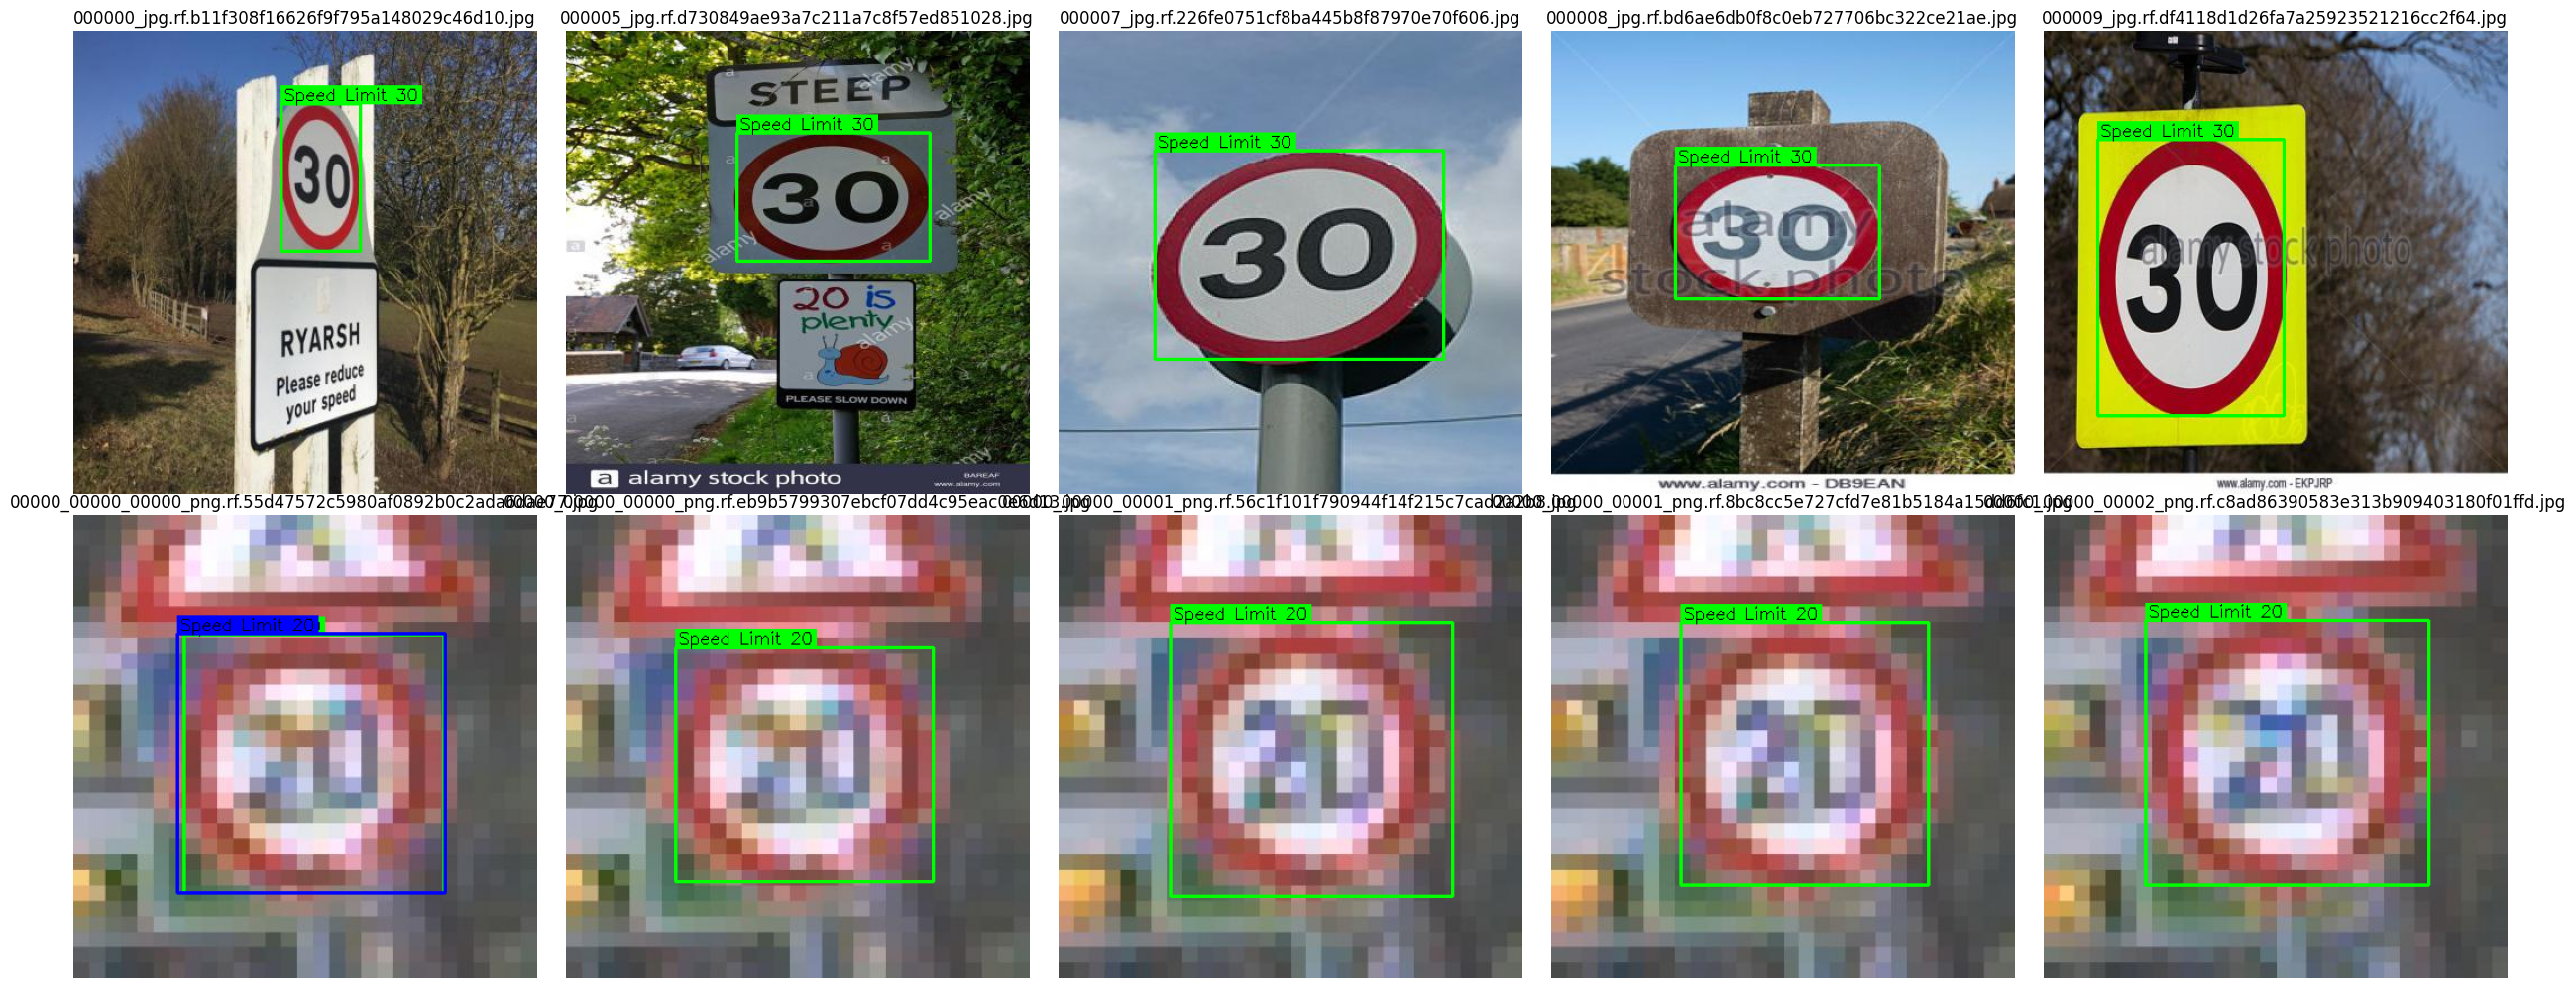

In [ ]:
base_dir = "datasets/Problema 2/Dataset - Ejercicio 2 - Traffic Signs Detection/car/train" 
images_dir = os.path.join(base_dir, "images")
labels_dir = os.path.join(base_dir, "labels")

#Mostramos las primeras 10 imágenes con sus anotaciones
image_files = [f for f in os.listdir(images_dir) if f.endswith(('.jpg', '.png', '.jpeg'))][:10]
fig, axes = plt.subplots(2, 5, figsize=(25, 10))

for ax, img_name in zip(axes.flatten(), image_files):
    img_path = os.path.join(images_dir, img_name)
    lbl_name = os.path.splitext(img_name)[0] + ".txt"
    lbl_path = os.path.join(labels_dir, lbl_name)
    if os.path.exists(lbl_path):
        img_bbox = visualizar_anotacion(img_path, lbl_path, names)
        ax.imshow(img_bbox)
    else:
        print(f"No se encontró etiqueta para {img_name}")
        
    ax.axis('off')
    ax.set_title(img_name)

plt.tight_layout()
plt.show()

## 2.2 Entrenamiento con YOLO

Se utilizan las variantes **Nano** (`yolo11n`) y **Small** (`yolo11s`) de YOLOv11. 

- `yolo11n` (Nano): menor cantidad de parámetros, entrenamiento más rápido, precisión algo menor.
- `yolo11s` (Small): más parámetros, mayor precisión esperada, entrenamiento más lento.

Se fija `seed=42` para reproducibilidad. El `device` se detecta automáticamente según disponibilidad de GPU.

In [ ]:
#Detección automática de cpu o gpu para entrenamiento
device = 0 if torch.cuda.is_available() else 'cpu'
print(f"Dispositivo de entrenamiento: {'GPU (cuda:0)' if device == 0 else 'CPU'}")

#Modelos a comparar: Nano vs Small
model_sizes = ["yolo11n.pt", "yolo11s.pt"]
epochs_to_train = 50
data_yaml = "datasets/Problema 2/Dataset - Ejercicio 2 - Traffic Signs Detection/car/data.yaml"

for size in model_sizes:
    print(f"\n--- Iniciando entrenamiento con el modelo: {size} ---")
    model = YOLO(size)
    run_name = size.split('.')[0]
    results = model.train(
        data=data_yaml,
        epochs=epochs_to_train,
        imgsz=640,
        project="tp2_senales",
        name=run_name,
        seed=42,
        device=device
    )
    print(f"--- Fin del entrenamiento para {size} ---\n")

Dispositivo de entrenamiento: GPU (cuda:0)

--- Iniciando entrenamiento con el modelo: yolo11n.pt ---
Ultralytics 8.4.60  Python-3.11.4 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060, 12287MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=datasets/Dataset - Ejercicio 2 - Traffic Signs Detection/car/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, 

Los dos modelos entrenaron sin errores. En la siguiente sección se analizan y comparan sus métricas.

## 2.3 Análisis de resultados del entrenamiento

Ultralytics guarda automáticamente en la carpeta del experimento las curvas de entrenamiento, 
las curvas PR/F1/P/R y las matrices de confusión. A continuación se cargan e interpretan 
para cada modelo.


Modelo: yolo11n
Ruta relativa encontrada: .\runs\detect\tp2_senales\yolo11n


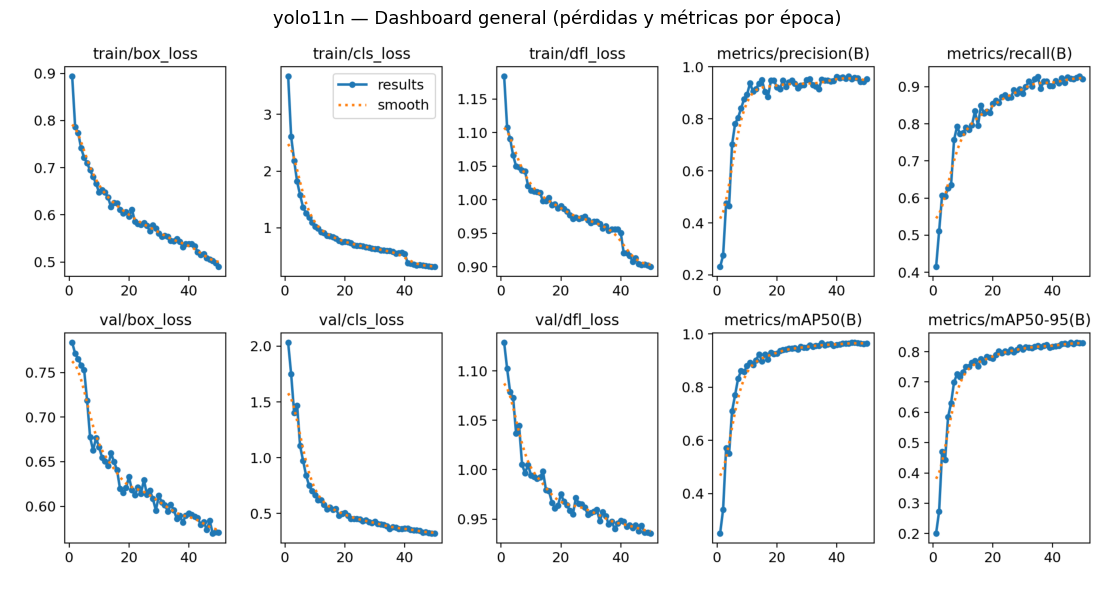

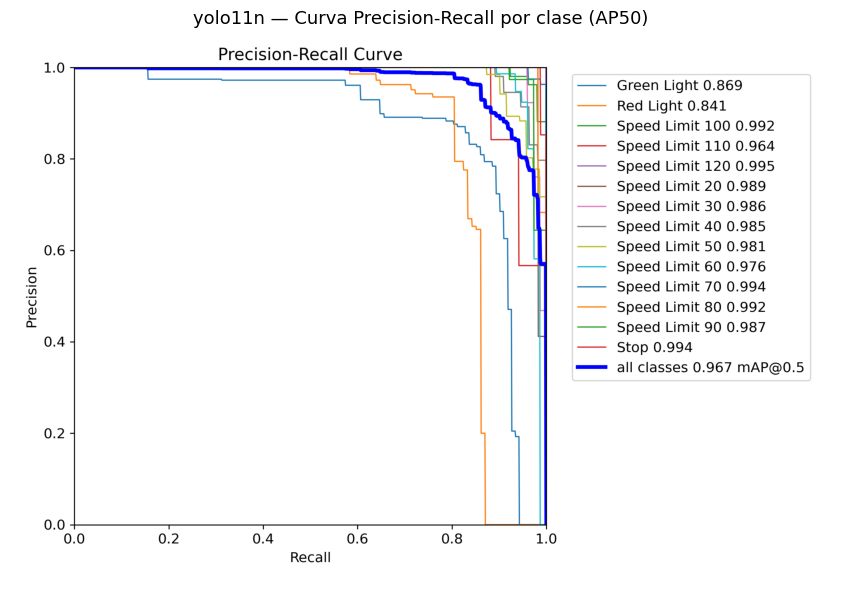

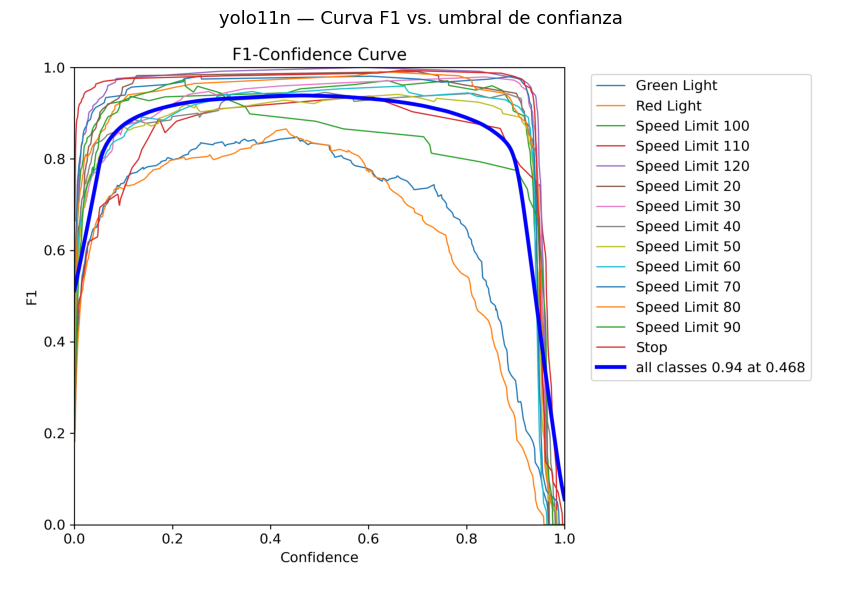

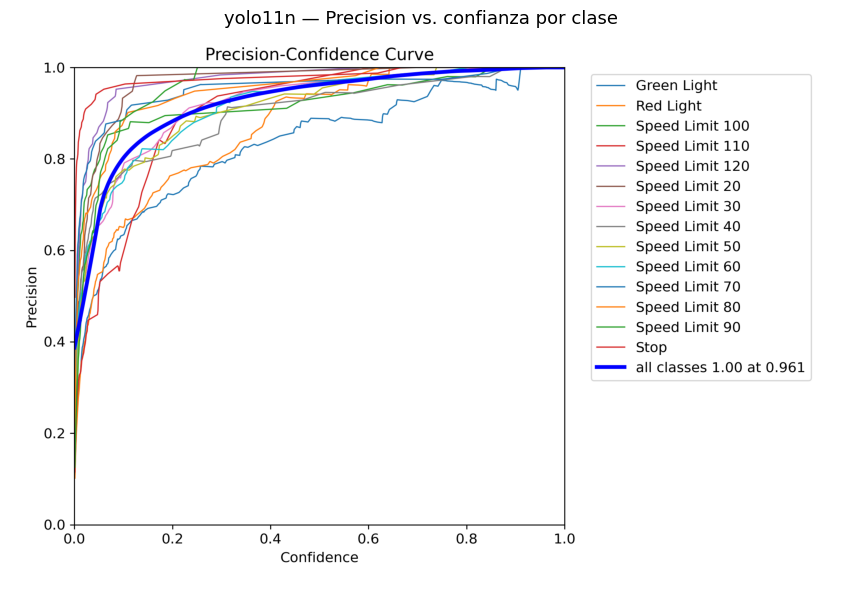

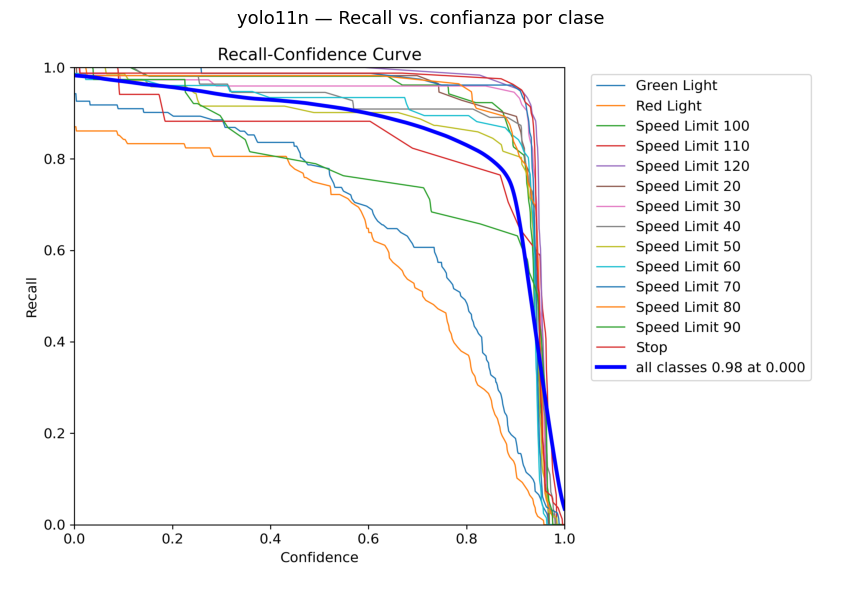

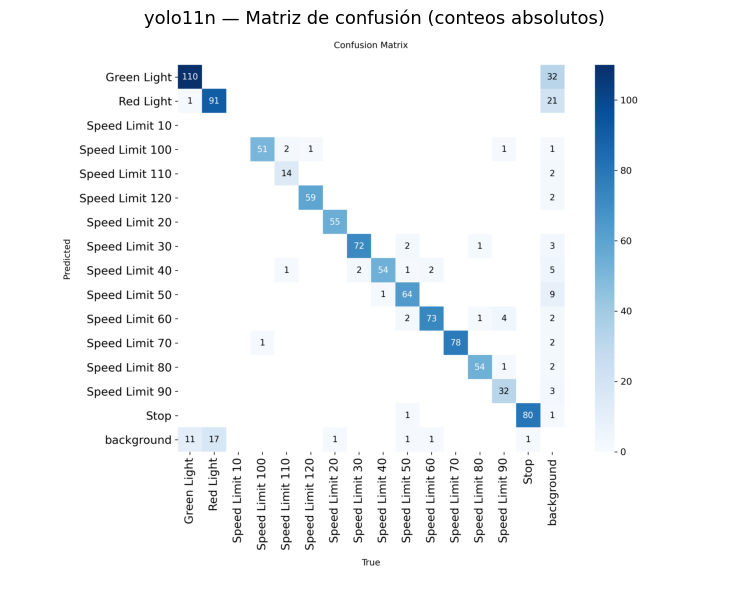

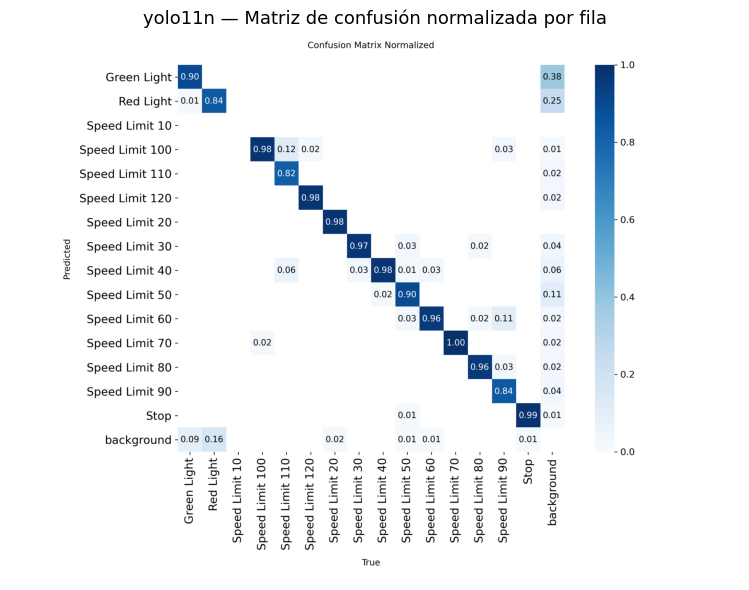


Modelo: yolo11s
Ruta relativa encontrada: .\runs\detect\tp2_senales\yolo11s


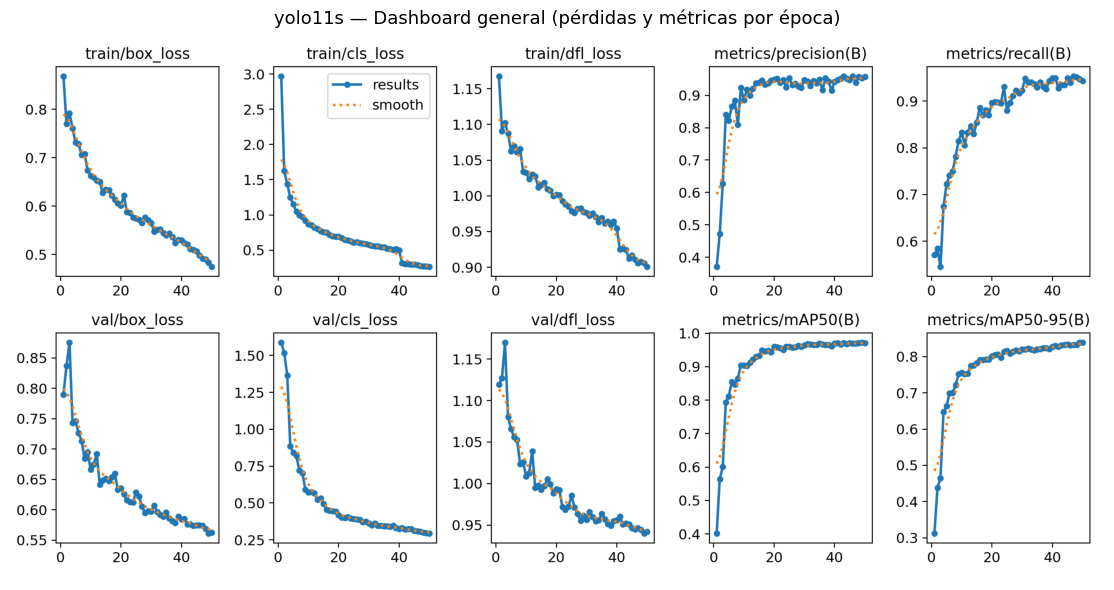

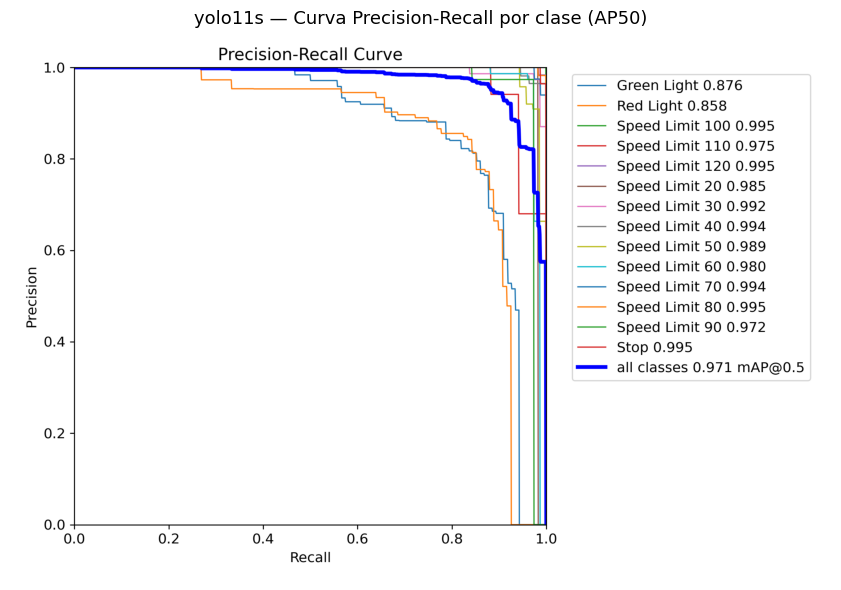

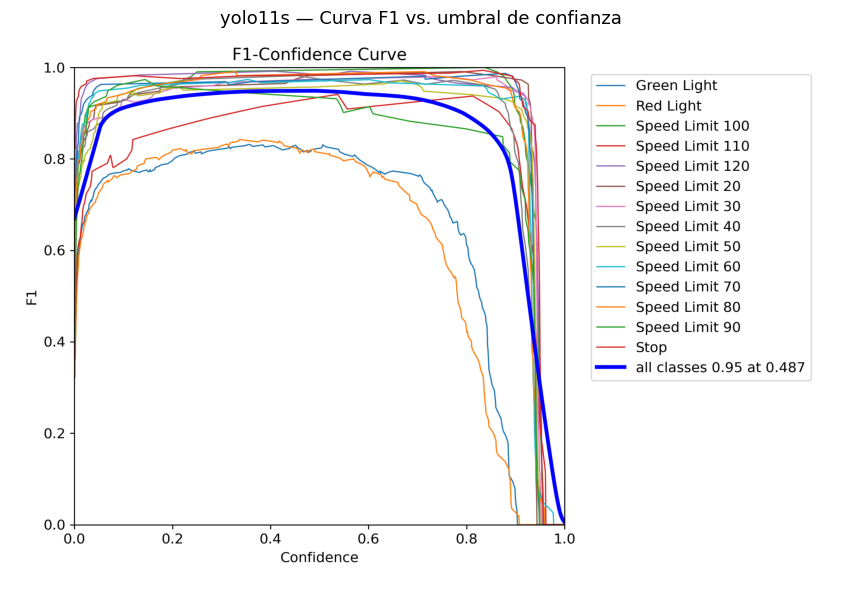

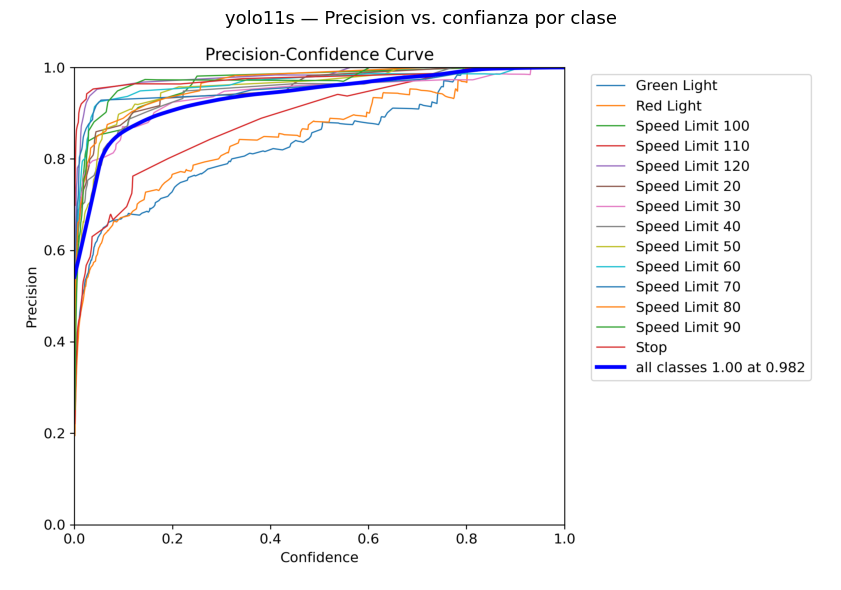

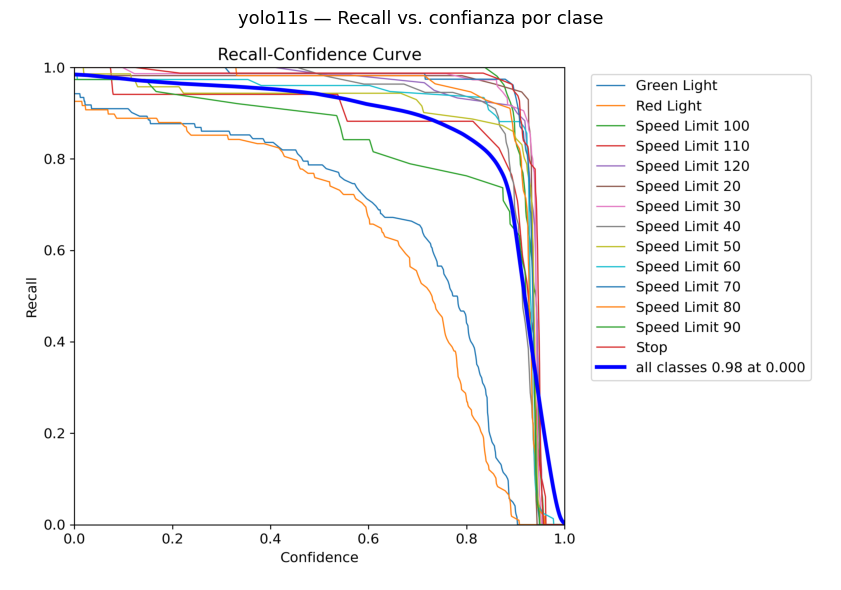

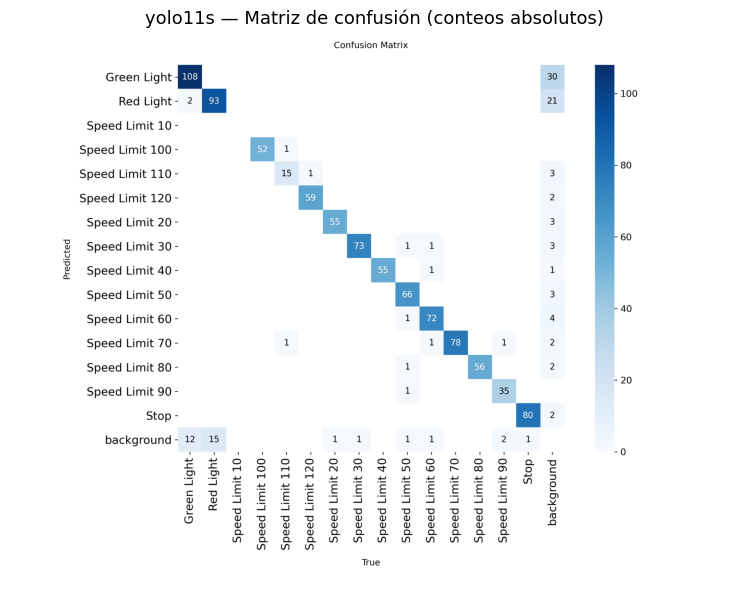

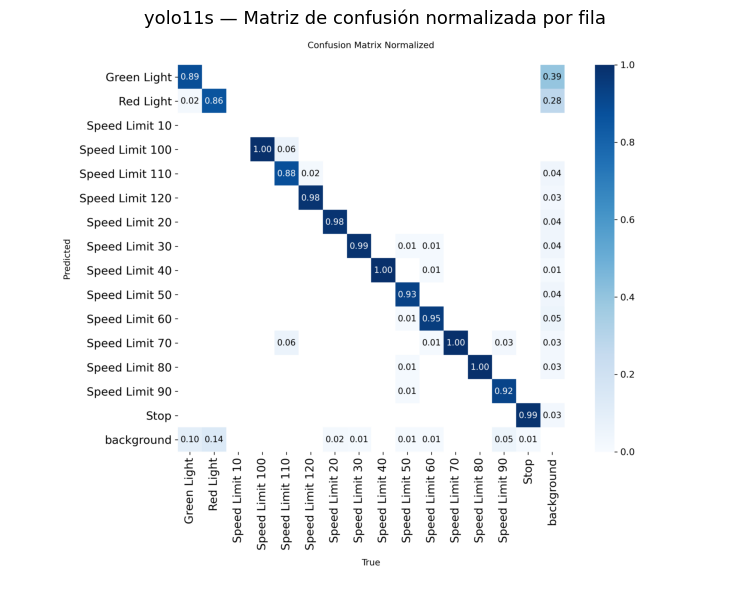

In [ ]:
base_dir = os.path.join(".", "runs", "detect", "tp2_senales")

def buscar_ultima_carpeta(base, prefijo):
    carpetas = glob.glob(os.path.join(base, f"{prefijo}*"))
    carpetas = [c for c in carpetas if os.path.isdir(c)]
    
    if not carpetas:
        return None
    return max(carpetas, key=os.path.getmtime)
run_dirs = {
    "yolo11n": buscar_ultima_carpeta(base_dir, "yolo11n"),
    "yolo11s": buscar_ultima_carpeta(base_dir, "yolo11s"),
}

archivos_analisis = [
    ("results.png",                    "Dashboard general (pérdidas y métricas por época)"),
    ("BoxPR_curve.png",                "Curva Precision-Recall por clase (AP50)"),
    ("BoxF1_curve.png",                "Curva F1 vs. umbral de confianza"),
    ("BoxP_curve.png",                 "Precision vs. confianza por clase"),
    ("BoxR_curve.png",                 "Recall vs. confianza por clase"),
    ("confusion_matrix.png",           "Matriz de confusión (conteos absolutos)"),
    ("confusion_matrix_normalized.png","Matriz de confusión normalizada por fila"),
]

for model_name, run_dir in run_dirs.items():
    print(f"\n{'='*60}")
    print(f"Modelo: {model_name}")
    
    if run_dir is None:
        print(f" [!] Error: No se encontró la carpeta para {model_name} en {base_dir}")
        print("="*60)
        continue
        
    print(f"Ruta relativa encontrada: {run_dir}")
    print(f"{'='*60}")
    
    for filename, description in archivos_analisis:
        img_path = os.path.join(run_dir, filename)
        
        if os.path.exists(img_path):
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            
            plt.figure(figsize=(14, 6))
            plt.imshow(img)
            plt.axis('off')
            plt.title(f"{model_name} — {description}", fontsize=13)
            plt.tight_layout()
            plt.show()
        else:
            print(f"  [!] No encontrado: {filename}")

### Interpretación de curvas — yolo11n vs yolo11s

**results.png:** Permite evaluar la convergencia del entrenamiento. Se observan las pérdidas de caja (`box_loss`), 
clasificación (`cls_loss`) y distribución focal (`dfl_loss`) tanto en train como en validación, junto con las métricas 
mAP@50 y mAP@50-95 por época.

**BoxPR_curve.png:** Muestra la curva Precision-Recall por clase a IoU=0.5. El área bajo cada curva es el AP50 individual. 
Clases con curvas más altas y más a la derecha tienen mejor rendimiento.

**BoxF1_curve.png:** Indica el umbral de confianza óptimo para inferencia (el que maximiza F1). 
Se puede usar este valor para ajustar el parámetro `conf` en `predict()`.

**BoxP_curve.png / BoxR_curve.png:** Muestran cómo evoluciona la precisión y el recall al variar el umbral de confianza. 
A mayor umbral, la precisión sube (menos falsos positivos) pero el recall cae (más falsos negativos).

**confusion_matrix_normalized.png:** Más útil que la absoluta para clases desbalanceadas. 
La diagonal principal representa los verdaderos positivos por clase. Valores altos fuera de la diagonal 
indican confusión entre clases similares (ej. límites de velocidad consecutivos como 80 km/h y 90 km/h).

### Tabla comparativa de métricas — yolo11n vs yolo11s

Se reportan las métricas obtenidas sobre el conjunto de test para cada modelo, 
junto con el tiempo promedio de inferencia por imagen.

In [ ]:
def buscar_ultima_carpeta(base, prefijo):
    carpetas = glob.glob(os.path.join(base, f"{prefijo}*"))
    carpetas = [c for c in carpetas if os.path.isdir(c)]
    if not carpetas:
        return None
    return max(carpetas, key=os.path.getmtime)
base_dir = os.path.join(".", "runs", "detect", "tp2_senales")
dir_n = buscar_ultima_carpeta(base_dir, "yolo11n")
dir_s = buscar_ultima_carpeta(base_dir, "yolo11s")

weights = {}
if dir_n: weights["yolo11n"] = os.path.join(dir_n, "weights", "best.pt")
if dir_s: weights["yolo11s"] = os.path.join(dir_s, "weights", "best.pt")

data_yaml = os.path.join("datasets", "Problema 2", "Dataset - Ejercicio 2 - Traffic Signs Detection", "car", "data.yaml")
metricas = {}

for model_name, weight_path in weights.items():
    if not os.path.exists(weight_path):
        print(f" [!] Error: No se encontró el archivo de pesos en {weight_path}")
        continue
        
    print(f"\n{'='*60}")
    print(f"Evaluando {model_name}...")
    print(f"Pesos: {weight_path}")
    print(f"{'='*60}")
    model = YOLO(weight_path)
    val_results = model.val(data=data_yaml, split='test', imgsz=640) 
    
    metricas[model_name] = {
        "mAP50":     val_results.box.map50,
        "mAP50-95":  val_results.box.map,
        "precision": val_results.box.mp,
        "recall":    val_results.box.mr,
    }

#Tabla comparativa de métricas
print("\n" + "="*60)
print(f"{'Modelo':<12} | {'mAP@50':>10} | {'mAP@50-95':>10} | {'Precision':>10} | {'Recall':>10}")
print("-" * 60)
for model_name, m in metricas.items():
    print(f"{model_name:<12} | {m['mAP50']:>10.4f} | {m['mAP50-95']:>10.4f} | {m['precision']:>10.4f} | {m['recall']:>10.4f}")
print("="*60)


Evaluando yolov11n...
Pesos: .\runs\detect\tp2_senales\yolo11n\weights\best.pt
Ultralytics 8.4.60  Python-3.11.4 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060, 12287MiB)
YOLO11n summary (fused): 101 layers, 2,585,077 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 209.0127.5 MB/s, size: 21.9 KB)
val: Scanning C:\Users\Sebas\TP2_AA2_ChiesPalacio\Datasets\Dataset - Ejercicio 2 - Traffic Signs Detection\car\test\labels... 638 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 638/638 1.8Kit/s 0.3s0.1ss
val: New cache created: C:\Users\Sebas\TP2_AA2_ChiesPalacio\Datasets\Dataset - Ejercicio 2 - Traffic Signs Detection\car\test\labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 40/40 5.9it/s 6.8s0.1s
                   all        638        770      0.919       0.93      0.955       0.81
           Green Light         77        110       0.86      0.827      0.908      0.562
     

In [ ]:
#Medición del tiempo promedio de inferencia por imagen (sobre las primeras 50 imágenes de test)
ruta_test_imgs = "datasets/Problema 2/Dataset - Ejercicio 2 - Traffic Signs Detection/car/test/images"
test_imgs = sorted(glob.glob(os.path.join(ruta_test_imgs, "*.jpg")))[:50]

tiempos_inferencia = {}
for model_name, weight_path in weights.items():
    model = YOLO(weight_path)
    model.predict(source=test_imgs[:3], verbose=False)
    t0 = time.perf_counter()
    model.predict(source=test_imgs, verbose=False)
    elapsed = time.perf_counter() - t0
    tiempos_inferencia[model_name] = elapsed / len(test_imgs) * 1000  #ms por imagen
    print(f"{model_name}: {tiempos_inferencia[model_name]:.2f} ms/imagen (promedio sobre {len(test_imgs)} imágenes)")

yolov11n: 8.36 ms/imagen (promedio sobre 50 imágenes)
yolov11s: 11.87 ms/imagen (promedio sobre 50 imágenes)


### Análisis del trade-off velocidad / precisión

| Modelo  | Parámetros | mAP@50 | mAP@50-95 | Precision | Recall | Tiempo entrenamiento | Inferencia  |
|---------|------------|--------|-----------|-----------|--------|----------------------|-------------|
| yolo11n | 2.6M       | 0.955  | 0.810     | 0.919     | 0.930  | 48.5 min             | 8.4 ms/img  |
| yolo11s | 9.4M       | 0.961  | 0.824     | 0.929     | 0.952  | 51.8 min             | 11.9 ms/img |

Ambos modelos alcanzan un rendimiento muy alto, con mAP@50 superior al 95% en el conjunto de test.
La diferencia entre ellos es pequeña pero consistente: `yolo11s` supera a `yolo11n` en todas las métricas,
con una mejora de +0.6 puntos en mAP@50 y +1.4 puntos en mAP@50-95. Sin embargo, este incremento tiene
un costo: ~3.6x más parámetros, 42% más tiempo de inferencia (11.9ms vs 8.4ms) y 3.3 minutos adicionales
de entrenamiento, una diferencia marginal en este caso dado el tamaño del dataset.

Las clases más difíciles para ambos modelos son **Green Light** y **Red Light**, con los mAP@50 más bajos
(~0.84–0.88 en val). Esto se explica porque los semáforos presentan mayor variabilidad visual: pueden
aparecer en distintos tamaños, con oclusiones parciales, y con variaciones de iluminación importantes
según el estado del tráfico. En contraste, las señales de velocidad son objetos con forma y texto
estandarizado, lo que facilita su detección.

Dentro de los límites de velocidad, **Speed Limit 10** es la clase con menos instancias en test (solo 3),
lo que hace que sus métricas tengan alta varianza y no sean estadísticamente representativas. El resto
de los límites de velocidad obtiene mAP@50 superior a 0.97 en ambos modelos.

Para un escenario con restricciones de latencia (ej. sistema embebido en un vehículo), `yolo11n` es la
mejor opción dado que su precisión es prácticamente equivalente y su inferencia es un 29% más rápida.
Si el sistema corre offline o en hardware sin restricciones de tiempo, `yolo11s` es preferible por su
mayor recall (0.952 vs 0.930), lo que implica menos señales no detectadas.

## 2.4 Predicciones sobre el conjunto de test

Se visualizan al menos 5 ejemplos de predicciones del mejor modelo (`yolo11s`) sobre imágenes del test, 
con bounding boxes y scores visibles.


image 1/638 c:\Users\Sebas\TP2_AA2_ChiesPalacio\datasets\Dataset - Ejercicio 2 - Traffic Signs Detection\car\test\images\000003_jpg.rf.8511b9c219dbf9799a6d58900b15917d.jpg: 640x640 1 Speed Limit 30, 10.2ms
image 2/638 c:\Users\Sebas\TP2_AA2_ChiesPalacio\datasets\Dataset - Ejercicio 2 - Traffic Signs Detection\car\test\images\000006_jpg.rf.89610ec419ccfab22f8314026b90ee26.jpg: 640x640 1 Speed Limit 30, 11.1ms
image 3/638 c:\Users\Sebas\TP2_AA2_ChiesPalacio\datasets\Dataset - Ejercicio 2 - Traffic Signs Detection\car\test\images\00000_00000_00003_png.rf.d18afc3c9625ffb1974029d3e3762aee.jpg: 640x640 1 Speed Limit 20, 9.3ms
image 4/638 c:\Users\Sebas\TP2_AA2_ChiesPalacio\datasets\Dataset - Ejercicio 2 - Traffic Signs Detection\car\test\images\00000_00000_00005_png.rf.ab60a274676963d378f5014e89d9e2b1.jpg: 640x640 1 Speed Limit 20, 11.7ms
image 5/638 c:\Users\Sebas\TP2_AA2_ChiesPalacio\datasets\Dataset - Ejercicio 2 - Traffic Signs Detection\car\test\images\00000_00000_00006_png.rf.9d1ea685

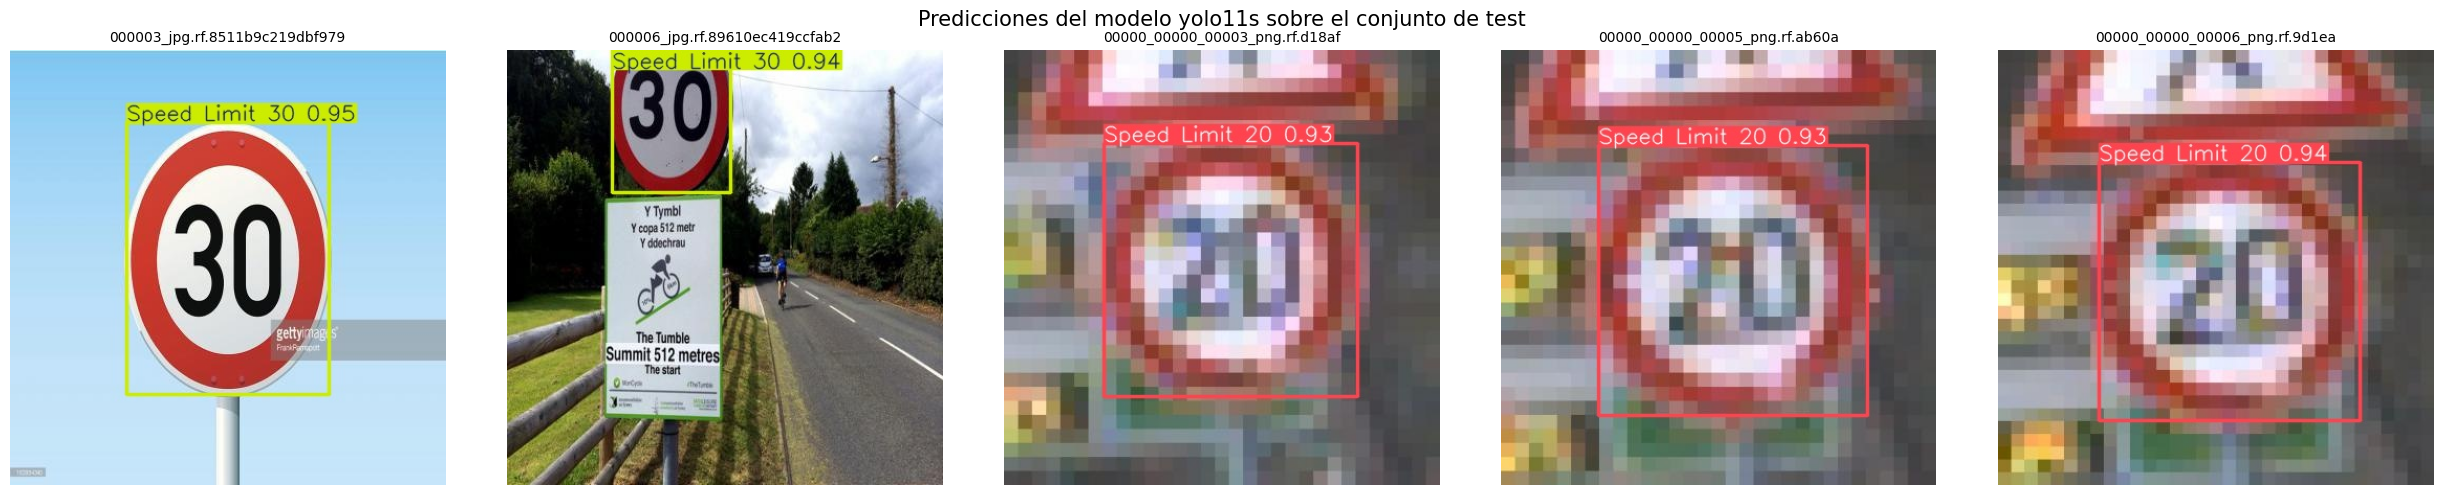

In [ ]:
def buscar_ultima_carpeta(base, prefijo):
    carpetas = glob.glob(os.path.join(base, f"{prefijo}*"))
    carpetas = [c for c in carpetas if os.path.isdir(c)]
    if not carpetas:
        return None
    return max(carpetas, key=os.path.getmtime)

base_dir = os.path.join(".", "runs", "detect", "tp2_senales")
dir_s = buscar_ultima_carpeta(base_dir, "yolo11s")

if dir_s is None:
    print("Error: No se encontró la carpeta del modelo yolo11s.")
else:
    mejor_modelo_path = os.path.join(dir_s, "weights", "best.pt")
    modelo_entrenado = YOLO(mejor_modelo_path)
    ruta_test = os.path.join("datasets", "Problema 2", "Dataset - Ejercicio 2 - Traffic Signs Detection", "car", "test", "images")
    resultados = modelo_entrenado.predict(
        source=ruta_test,
        save=True,
        project=os.path.join("runs", "detect"), 
        name="predicciones_test_yolo11s",
        exist_ok=True
    )
    carpeta_salida = resultados[0].save_dir
    rutas_predicciones = sorted(
        [f for f in glob.glob(os.path.join(carpeta_salida, "*.*"))
         if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
    )[:5]
    
    if not rutas_predicciones:
        print("No se encontraron imágenes en:", carpeta_salida)
    else:
        fig, axes = plt.subplots(1, 5, figsize=(25, 5))
        fig.suptitle("Predicciones del modelo yolo11s sobre el conjunto de test", fontsize=15)
        
        for ax, img_path in zip(axes, rutas_predicciones):
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            ax.imshow(img)
            ax.axis('off')
            ax.set_title(os.path.basename(img_path)[:30], fontsize=10)
            
        plt.tight_layout()
        plt.show()

Las predicciones muestran que el modelo detecta correctamente la mayoría de señales con alta confianza. 
En los ejemplos que se imprimieron, podemos visualizar que detecta señales de speed limit 30km/h con un 0.94 de confianza y los speed limit 20km/h con 0.93 de confianza, ambos siendo porcentajes muy buenos y acertados.

## 2.5 Análisis sobre video

Se aplica el modelo entrenado sobre el video provisto en el dataset para observar el comportamiento 
del detector en una secuencia temporal continua. El resultado se guarda en la carpeta del proyecto 
usando rutas relativas.

In [ ]:
ruta_video = "datasets/Problema 2/Dataset - Ejercicio 2 - Traffic Signs Detection/video.mp4"

resultados_video = modelo_entrenado.predict(
    source=ruta_video,
    save=True,
    project="tp2_senales",
    name="predicciones_video_yolov11s",
    exist_ok=True
)

print(f"Video procesado. Resultados guardados en: {resultados_video[0].save_dir}")


WARNING 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/508) c:\Users\Sebas\TP2_AA2_ChiesPalacio\datasets\Dataset - Ejercicio 2 - Traffic Signs Detection\video.mp4: 640x640 1 Stop, 236.8ms
video 1/1 (frame 2/508) c:\Users\Sebas\TP2_AA2_ChiesPalacio\datasets\Dataset - Ejercicio 2 - Traffic Signs Detection\video.mp4: 640x640 1 Stop, 10.0ms
video 1/1 (frame 3/508) c:\Users\Sebas\TP2_AA2_ChiesPalacio\datasets\Dataset - Ejercicio 2 - Traffic Signs Detection\video.mp4: 640x640 1 Stop, 13.7ms
video 1